# 01 Dataset Verification — 50-Painting Controlled Subset

This notebook verifies the raw 50-painting controlled subset before preprocessing.

It checks:

1. experiment configuration,
2. metadata structure,
3. category balance,
4. expected source split,
5. referenced image files,
6. image readability and basic properties,
7. a compact visual preview,
8. a saved verification summary.

This notebook intentionally stops after raw dataset verification. Preprocessing, mask generation, restoration, metrics, and reports are handled in later notebooks.

In [1]:
from pathlib import Path
import sys
import yaml

# Resolve project root whether this notebook is run from project root or notebooks/
PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

CONFIG_PATH = PROJECT_ROOT / "config" / "experiment_50_config.yaml"

print("Project root:", PROJECT_ROOT)
print("Source directory:", SRC_DIR)
print("Source directory exists:", SRC_DIR.exists())
print("Config path:", CONFIG_PATH)
print("Config exists:", CONFIG_PATH.exists())

if not SRC_DIR.exists():
    raise FileNotFoundError(f"Source directory not found: {SRC_DIR}")

if not CONFIG_PATH.exists():
    raise FileNotFoundError(f"Experiment config not found: {CONFIG_PATH}")

Project root: D:\Masters\FH\Thesis\painting-restoration-eval
Source directory: D:\Masters\FH\Thesis\painting-restoration-eval\src
Source directory exists: True
Config path: D:\Masters\FH\Thesis\painting-restoration-eval\config\experiment_50_config.yaml
Config exists: True


In [3]:
with CONFIG_PATH.open("r", encoding="utf-8") as f:
    config = yaml.safe_load(f)

print("Loaded config keys:")
print(list(config.keys()))

experiment = config.get("experiment", {})
dataset = config.get("dataset", {})
paths_cfg = config.get("paths", {})

print("\nExperiment:")
for key, value in experiment.items():
    print(f"  {key}: {value}")

print("\nDataset:")
for key, value in dataset.items():
    if key == "categories":
        print("  categories:")
        for category, count in value.items():
            print(f"    {category}: {count}")
    else:
        print(f"  {key}: {value}")

raw_images_dir = PROJECT_ROOT / paths_cfg["raw_image_dir"]
raw_metadata_path = PROJECT_ROOT / paths_cfg["metadata_path"]

metrics_dir = PROJECT_ROOT / paths_cfg["metrics_dir"]
figures_dir = PROJECT_ROOT / paths_cfg["figures_dir"]
reports_dir = PROJECT_ROOT / paths_cfg["reports_dir"]

verification_summary_path = PROJECT_ROOT / "outputs" / "dataset_verification_summary.csv"

print("\nResolved paths:")
print("  Raw images dir:", raw_images_dir)
print("  Raw images dir exists:", raw_images_dir.exists())
print("  Raw metadata path:", raw_metadata_path)
print("  Raw metadata exists:", raw_metadata_path.exists())
print("  Metrics dir:", metrics_dir)
print("  Figures dir:", figures_dir)
print("  Reports dir:", reports_dir)
print("  Verification summary path:", verification_summary_path)

if not raw_images_dir.exists():
    raise FileNotFoundError(f"Raw images directory not found: {raw_images_dir}")

if not raw_metadata_path.exists():
    raise FileNotFoundError(f"Raw metadata file not found: {raw_metadata_path}")

metrics_dir.mkdir(parents=True, exist_ok=True)
figures_dir.mkdir(parents=True, exist_ok=True)
reports_dir.mkdir(parents=True, exist_ok=True)
verification_summary_path.parent.mkdir(parents=True, exist_ok=True)

Loaded config keys:
['experiment', 'paths', 'dataset', 'preprocessing', 'damage_conditions', 'models', 'metrics', 'reporting', 'notes']

Experiment:
  name: painting_restoration_50_subset
  phase: controlled_subset
  description: Controlled 50-painting evaluation subset for AI-assisted painting restoration.
  image_size: 768
  random_seed: 42

Dataset:
  total_paintings: 50
  categories:
    portrait_figure: 10
    landscape_natural: 10
    architecture_structured: 10
    abstraction_surrealism: 10
    high_texture_brushwork: 10
  selection_rules: ['Use public-domain or open-access images only.', 'Use images with sufficient resolution for 768x768 preprocessing.', 'Record source URL and license for each painting.', 'Select images based on restoration-relevant visual properties, not only art-historical category.']

Resolved paths:
  Raw images dir: D:\Masters\FH\Thesis\painting-restoration-eval\data\raw\images
  Raw images dir exists: True
  Raw metadata path: D:\Masters\FH\Thesis\painti

In [4]:
import pandas as pd

metadata_df = pd.read_csv(raw_metadata_path)

print("Metadata loaded successfully.")
print("Shape:", metadata_df.shape)

print("\nColumns:")
for col in metadata_df.columns:
    print(f"  - {col}")

print("\nFirst 5 rows:")
display(metadata_df.head())

print("\nMissing values by column:")
missing_counts = metadata_df.isna().sum()
display(missing_counts[missing_counts > 0].sort_values(ascending=False))

Metadata loaded successfully.
Shape: (50, 17)

Columns:
  - painting_id
  - category
  - title
  - artist
  - date
  - style_or_period
  - medium
  - source
  - source_url
  - license
  - filename
  - original_width
  - original_height
  - selection_reason
  - visual_complexity_note
  - status
  - notes

First 5 rows:


,painting_id,category,title,artist,date,style_or_period,medium,source,source_url,license,filename,original_width,original_height,selection_reason,visual_complexity_note,status,notes
0,p001,portrait_figure,Juan de Pareja,Diego Velázquez,1650,Baroque,Oil on canvas,The Metropolitan Museum of Art,https://www.metmuseum.org/art/collection/searc...,Public Domain / Open Access,p001.jpg,3427,3968,Classic portrait baseline with strong face and...,Single male portrait with dark background and ...,selected,Met Open Access.
1,p002,portrait_figure,Madame X (Madame Pierre Gautreau),John Singer Sargent,1883-84,19th century portraiture,Oil on canvas,The Metropolitan Museum of Art,https://www.metmuseum.org/art/collection/searc...,Public Domain / Open Access,p002.jpg,2336,4000,Full-figure portrait with strong silhouette an...,"Figure, skin, dress, and pose create useful re...",selected,Met Open Access.
2,p003,portrait_figure,Marie Joséphine Charlotte du Val d'Ognes,Marie-Denise Villers,1801,Neoclassical / early 19th century,Oil on canvas,The Metropolitan Museum of Art,https://www.metmuseum.org/art/collection/searc...,Public Domain / Open Access,p003.jpg,3098,3872,Distinct portrait composition with studio cont...,"Face, hands, clothing, and background objects.",selected,Met Open Access.
3,p004,portrait_figure,Madame Georges Charpentier and Her Children,Pierre-Auguste Renoir,1878,Impressionism,Oil on canvas,The Metropolitan Museum of Art,https://www.metmuseum.org/art/collection/searc...,Public Domain / Open Access,p004.jpg,4000,3254,Multi-person portrait with larger composition.,"Multiple faces, fabrics, children, and interio...",selected,Met Open Access.
4,p005,portrait_figure,Self-Portrait with Two Pupils,Adélaïde Labille-Guiard,1785,18th century portraiture,Oil on canvas,The Metropolitan Museum of Art,https://www.metmuseum.org/art/collection/searc...,Public Domain / Open Access,p005.jpg,2884,3894,Multi-figure studio portrait.,"Faces, fabrics, and painter-at-work setting.",selected,Met Open Access.



Missing values by column:


date               32
style_or_period    32
medium             32
dtype: int64

In [5]:
# Core metadata validation

required_columns = [
    "painting_id",
    "category",
    "title",
    "artist",
    "source",
    "source_url",
    "license",
    "filename",
    "original_width",
    "original_height",
    "selection_reason",
    "visual_complexity_note",
    "status",
]

missing_required_columns = [col for col in required_columns if col not in metadata_df.columns]

print("Required column check:")
if missing_required_columns:
    print("Missing required columns:")
    for col in missing_required_columns:
        print(f"  - {col}")
else:
    print("All required columns are present.")

expected_total = dataset.get("total_paintings", 50)
actual_total = len(metadata_df)

print("\nRow count check:")
print("Expected total paintings:", expected_total)
print("Actual metadata rows:", actual_total)

if actual_total != expected_total:
    print("WARNING: Metadata row count does not match expected total.")
else:
    print("Metadata row count matches expected total.")

print("\nPainting ID uniqueness:")
print("Unique painting IDs:", metadata_df["painting_id"].nunique())
print("Duplicate painting IDs:", metadata_df["painting_id"].duplicated().sum())

print("\nFilename uniqueness:")
print("Unique filenames:", metadata_df["filename"].nunique())
print("Duplicate filenames:", metadata_df["filename"].duplicated().sum())

print("\nStatus counts:")
display(metadata_df["status"].value_counts(dropna=False))

if missing_required_columns:
    raise ValueError("Core metadata schema check failed. Fix missing required columns before continuing.")

if metadata_df["painting_id"].duplicated().any():
    raise ValueError("Duplicate painting_id values found.")

if metadata_df["filename"].duplicated().any():
    raise ValueError("Duplicate filename values found.")

Required column check:
All required columns are present.

Row count check:
Expected total paintings: 50
Actual metadata rows: 50
Metadata row count matches expected total.

Painting ID uniqueness:
Unique painting IDs: 50
Duplicate painting IDs: 0

Filename uniqueness:
Unique filenames: 50
Duplicate filenames: 0

Status counts:


status
selected    50
Name: count, dtype: int64

In [6]:
# Category and source split validation

expected_categories = dataset.get("categories", {})

print("Expected category counts from config:")
for category, expected_count in expected_categories.items():
    print(f"  {category}: {expected_count}")

actual_category_counts = metadata_df["category"].value_counts().sort_index()

print("\nActual category counts:")
display(actual_category_counts)

category_validation_rows = []

for category, expected_count in expected_categories.items():
    actual_count = int(actual_category_counts.get(category, 0))
    category_validation_rows.append(
        {
            "category": category,
            "expected_count": expected_count,
            "actual_count": actual_count,
            "matches_expected": actual_count == expected_count,
        }
    )

category_validation_df = pd.DataFrame(category_validation_rows)

print("\nCategory validation:")
display(category_validation_df)

unexpected_categories = sorted(set(metadata_df["category"]) - set(expected_categories.keys()))
missing_categories = sorted(set(expected_categories.keys()) - set(metadata_df["category"]))

print("\nUnexpected categories:", unexpected_categories)
print("Missing categories:", missing_categories)

if not category_validation_df["matches_expected"].all():
    raise ValueError("Category counts do not match the expected 5 × 10 design.")

if unexpected_categories:
    raise ValueError(f"Unexpected categories found: {unexpected_categories}")

print("\nSource counts by category:")
source_by_category = (
    metadata_df
    .groupby(["category", "source"])
    .size()
    .reset_index(name="count")
    .sort_values(["category", "source"])
)
display(source_by_category)

Expected category counts from config:
  portrait_figure: 10
  landscape_natural: 10
  architecture_structured: 10
  abstraction_surrealism: 10
  high_texture_brushwork: 10

Actual category counts:


category
abstraction_surrealism     10
architecture_structured    10
high_texture_brushwork     10
landscape_natural          10
portrait_figure            10
Name: count, dtype: int64


Category validation:


,category,expected_count,actual_count,matches_expected
0,portrait_figure,10,10,True
1,landscape_natural,10,10,True
2,architecture_structured,10,10,True
3,abstraction_surrealism,10,10,True
4,high_texture_brushwork,10,10,True



Unexpected categories: []
Missing categories: []

Source counts by category:


,category,source,count
0,abstraction_surrealism,Art Institute of Chicago,10
1,architecture_structured,Rijksmuseum,10
2,high_texture_brushwork,The Metropolitan Museum of Art,10
3,landscape_natural,The Metropolitan Museum of Art,10
4,portrait_figure,The Metropolitan Museum of Art,10


In [7]:
from PIL import Image

verification_rows = []

for _, row in metadata_df.iterrows():
    painting_id = row["painting_id"]
    filename = row["filename"]
    image_path = raw_images_dir / filename

    file_exists = image_path.exists()
    image_readable = False
    actual_width = None
    actual_height = None
    image_mode = None
    image_format = None
    issue = ""

    if not file_exists:
        issue = "missing_file"
    else:
        try:
            with Image.open(image_path) as img:
                image_readable = True
                actual_width, actual_height = img.size
                image_mode = img.mode
                image_format = img.format
        except Exception as exc:
            issue = f"unreadable_image: {type(exc).__name__}: {exc}"

    metadata_width = row.get("original_width")
    metadata_height = row.get("original_height")

    width_matches_metadata = (
        pd.notna(metadata_width)
        and actual_width is not None
        and int(metadata_width) == int(actual_width)
    )

    height_matches_metadata = (
        pd.notna(metadata_height)
        and actual_height is not None
        and int(metadata_height) == int(actual_height)
    )

    if file_exists and image_readable:
        if not width_matches_metadata or not height_matches_metadata:
            issue = "dimension_mismatch"

    verification_rows.append(
        {
            "painting_id": painting_id,
            "filename": filename,
            "category": row["category"],
            "source": row["source"],
            "file_path": str(image_path.relative_to(PROJECT_ROOT)),
            "file_exists": file_exists,
            "image_readable": image_readable,
            "metadata_width": metadata_width,
            "metadata_height": metadata_height,
            "actual_width": actual_width,
            "actual_height": actual_height,
            "width_matches_metadata": width_matches_metadata,
            "height_matches_metadata": height_matches_metadata,
            "image_mode": image_mode,
            "image_format": image_format,
            "issue": issue,
        }
    )

verification_df = pd.DataFrame(verification_rows)

print("Verification rows:", len(verification_df))
print("Missing files:", int((~verification_df["file_exists"]).sum()))
print("Unreadable images:", int((~verification_df["image_readable"]).sum()))
print("Dimension mismatches:", int((verification_df["issue"] == "dimension_mismatch").sum()))

print("\nIssue counts:")
display(verification_df["issue"].replace("", "ok").value_counts())

display(verification_df.head())

Verification rows: 50
Missing files: 0
Unreadable images: 0
Dimension mismatches: 0

Issue counts:


issue
ok    50
Name: count, dtype: int64

,painting_id,filename,category,source,file_path,file_exists,image_readable,metadata_width,metadata_height,actual_width,actual_height,width_matches_metadata,height_matches_metadata,image_mode,image_format,issue
0,p001,p001.jpg,portrait_figure,The Metropolitan Museum of Art,data\raw\images\p001.jpg,True,True,3427,3968,3427,3968,True,True,RGB,JPEG,
1,p002,p002.jpg,portrait_figure,The Metropolitan Museum of Art,data\raw\images\p002.jpg,True,True,2336,4000,2336,4000,True,True,RGB,JPEG,
2,p003,p003.jpg,portrait_figure,The Metropolitan Museum of Art,data\raw\images\p003.jpg,True,True,3098,3872,3098,3872,True,True,RGB,JPEG,
3,p004,p004.jpg,portrait_figure,The Metropolitan Museum of Art,data\raw\images\p004.jpg,True,True,4000,3254,4000,3254,True,True,RGB,JPEG,
4,p005,p005.jpg,portrait_figure,The Metropolitan Museum of Art,data\raw\images\p005.jpg,True,True,2884,3894,2884,3894,True,True,RGB,JPEG,


In [8]:
# Metadata completeness audit

metadata_completeness_rows = []

for column in metadata_df.columns:
    total_values = len(metadata_df)
    missing_values = int(metadata_df[column].isna().sum())
    present_values = total_values - missing_values
    missing_percentage = round((missing_values / total_values) * 100, 2)

    metadata_completeness_rows.append(
        {
            "column": column,
            "present_values": present_values,
            "missing_values": missing_values,
            "missing_percentage": missing_percentage,
        }
    )

metadata_completeness_df = (
    pd.DataFrame(metadata_completeness_rows)
    .sort_values(["missing_values", "column"], ascending=[False, True])
    .reset_index(drop=True)
)

print("Metadata completeness summary:")
display(metadata_completeness_df)

metadata_limitations_df = metadata_completeness_df[
    metadata_completeness_df["missing_values"] > 0
].copy()

print("\nColumns with missing values:")
display(metadata_limitations_df)

Metadata completeness summary:


,column,present_values,missing_values,missing_percentage
0,date,18,32,64.0
1,medium,18,32,64.0
2,style_or_period,18,32,64.0
3,artist,50,0,0.0
4,category,50,0,0.0
5,filename,50,0,0.0
6,license,50,0,0.0
7,notes,50,0,0.0
8,original_height,50,0,0.0
9,original_width,50,0,0.0



Columns with missing values:


,column,present_values,missing_values,missing_percentage
0,date,18,32,64.0
1,medium,18,32,64.0
2,style_or_period,18,32,64.0


In [9]:
# Save dataset verification summary

verification_summary_path.parent.mkdir(parents=True, exist_ok=True)

verification_df.to_csv(verification_summary_path, index=False)

print("Saved dataset verification summary:")
print(verification_summary_path)

print("\nSaved file exists:", verification_summary_path.exists())
print("Rows saved:", len(verification_df))

# Compact experiment-level summary for notebook output
dataset_summary = {
    "metadata_rows": len(metadata_df),
    "expected_total_paintings": expected_total,
    "files_checked": len(verification_df),
    "missing_files": int((~verification_df["file_exists"]).sum()),
    "unreadable_images": int((~verification_df["image_readable"]).sum()),
    "dimension_mismatches": int((verification_df["issue"] == "dimension_mismatch").sum()),
    "categories": metadata_df["category"].nunique(),
    "sources": metadata_df["source"].nunique(),
}

print("\nDataset summary:")
for key, value in dataset_summary.items():
    print(f"  {key}: {value}")

Saved dataset verification summary:
D:\Masters\FH\Thesis\painting-restoration-eval\outputs\dataset_verification_summary.csv

Saved file exists: True
Rows saved: 50

Dataset summary:
  metadata_rows: 50
  expected_total_paintings: 50
  files_checked: 50
  missing_files: 0
  unreadable_images: 0
  dimension_mismatches: 0
  categories: 5
  sources: 3


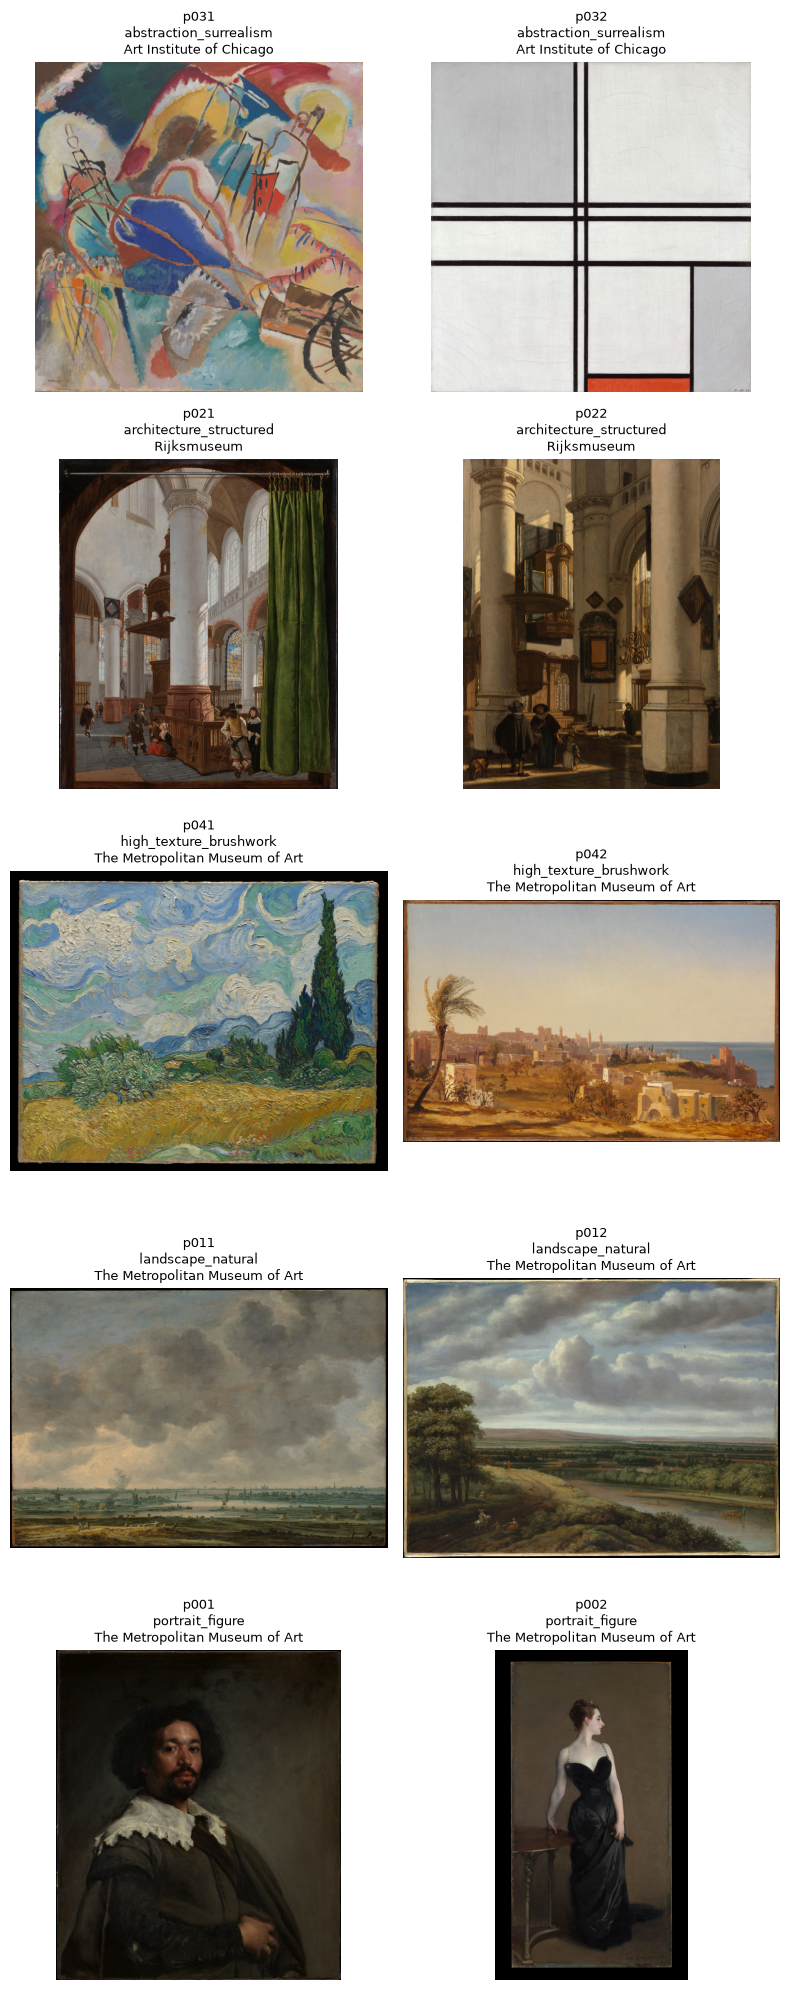

In [10]:
import matplotlib.pyplot as plt

preview_per_category = 2

preview_df = (
    metadata_df
    .sort_values(["category", "painting_id"])
    .groupby("category", group_keys=False)
    .head(preview_per_category)
    .reset_index(drop=True)
)

num_images = len(preview_df)
cols = preview_per_category
rows = metadata_df["category"].nunique()

fig, axes = plt.subplots(rows, cols, figsize=(cols * 4, rows * 4))

if rows == 1:
    axes = [axes]

for ax, (_, row) in zip(axes.flatten(), preview_df.iterrows()):
    image_path = raw_images_dir / row["filename"]

    with Image.open(image_path) as img:
        ax.imshow(img.convert("RGB"))

    title = f"{row['painting_id']}\n{row['category']}\n{row['source']}"
    ax.set_title(title, fontsize=9)
    ax.axis("off")

# Hide unused axes, if any
for ax in axes.flatten()[num_images:]:
    ax.axis("off")

plt.tight_layout()
plt.show()

## Verification result

The 50-painting controlled subset has been verified successfully.

Summary:

- 50 metadata records were loaded.
- All referenced raw image files were found.
- All images were readable.
- Recorded dimensions matched the actual image dimensions.
- The dataset follows the planned 5 × 10 category structure.
- The verification summary was saved for later notebooks and report generation.